# Ebola Outbreak Prediction — Member 2: Feature Engineering & Machine Learning

**Role:** Feature engineering, model training (Random Forest, Gradient Boosting),
chronological train-test split, and evaluation (MAE, RMSE, R², MASE).

**Input:** `ebola_environmental_merged.csv` — Guinea and Sierra Leone, 2014–2016,
with cumulative case/death counts and daily temperature, rainfall, and relative
humidity (from Member 1).

**Contents of this notebook:**
1. Load data
2. Feature engineering (lag + rolling window features, per country)
3. Chronological train/test split
4. Model training — Random Forest & Gradient Boosting
5. Evaluation — MAE, RMSE, R², and MASE against a naive baseline
6. A key finding about target framing (cumulative vs. incident cases) that
   changes how the results should be read


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


## 1. Load data

In [2]:
def load_data(path):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.rename(columns={
        "Cumulative no. of confirmed, probable and suspected cases": "Cases",
        "Cumulative no. of confirmed, probable and suspected deaths": "Deaths",
    })
    df = df.sort_values(["Country", "Date"]).reset_index(drop=True)
    return df

df = load_data("ebola_environmental_merged.csv")
print(df.shape)
df.head()


(518, 7)


,Country,Date,Cases,Deaths,Temperature,Rainfall,Relative_Humidity
0,Guinea,2014-08-29,648.0,430.0,25.2,1.0,86
1,Guinea,2014-09-05,812.0,517.0,25.0,4.3,86
2,Guinea,2014-09-08,862.0,555.0,24.4,13.3,87
3,Guinea,2014-09-12,861.0,557.0,25.0,1.6,84
4,Guinea,2014-09-16,936.0,595.0,24.0,55.6,91


## 2. Feature engineering

Lag features (t-1, t-2, t-3, t-7) and rolling mean/std (3, 7, 14-report windows)
are built **per country**, so no information crosses the Guinea/Sierra Leone
boundary. Rolling stats are computed on the *lagged* series (shifted by 1
first) so the current row's own value never leaks into its own rolling window.

We also derive `NewCases` / `NewDeaths` — the day-over-day change in the
cumulative counts — because this turns out to matter a lot (see Section 6).

A `days_since_prev` feature captures the irregular reporting gaps in the
data (most reports are ~daily, but gaps of several weeks appear later in
the outbreak as reporting slowed).

In [3]:
def build_features(df, lags=(1, 2, 3, 7), rolling_windows=(3, 7, 14)):
    out_frames = []
    for country, g in df.groupby("Country"):
        g = g.sort_values("Date").reset_index(drop=True)

        g["NewCases"] = g["Cases"].diff().clip(lower=0)
        g["NewDeaths"] = g["Deaths"].diff().clip(lower=0)

        base_cols = ["Cases", "Deaths", "NewCases", "NewDeaths",
                     "Temperature", "Rainfall", "Relative_Humidity"]

        for col in base_cols:
            for lag in lags:
                g[f"{col}_lag{lag}"] = g[col].shift(lag)

        for col in ["Cases", "Deaths", "NewCases", "Temperature", "Rainfall"]:
            shifted = g[col].shift(1)
            for w in rolling_windows:
                g[f"{col}_rollmean{w}"] = shifted.rolling(w).mean()
                g[f"{col}_rollstd{w}"] = shifted.rolling(w).std()

        g["days_since_prev"] = g["Date"].diff().dt.days
        out_frames.append(g)

    return pd.concat(out_frames, ignore_index=True)


def make_target(df, target_col="Cases", horizon=1):
    df = df.copy()
    df["target"] = df.groupby("Country")[target_col].shift(-horizon)
    return df

feat_df = build_features(df)
feat_df.filter(like="Cases").head()


,Cases,NewCases,Cases_lag1,Cases_lag2,Cases_lag3,Cases_lag7,NewCases_lag1,NewCases_lag2,NewCases_lag3,NewCases_lag7,Cases_rollmean3,Cases_rollstd3,Cases_rollmean7,Cases_rollstd7,Cases_rollmean14,Cases_rollstd14,NewCases_rollmean3,NewCases_rollstd3,NewCases_rollmean7,NewCases_rollstd7,NewCases_rollmean14,NewCases_rollstd14
0,648.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,812.0,164.0,648.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,862.0,50.0,812.0,648.0,NaN,NaN,164.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,861.0,0.0,862.0,812.0,648.0,NaN,50.0,164.0,NaN,NaN,774.0,111.946416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,936.0,75.0,861.0,862.0,812.0,NaN,0.0,50.0,164.0,NaN,845.0,28.583212,NaN,NaN,NaN,NaN,71.333333,84.055537,NaN,NaN,NaN,NaN


## 3. Chronological train-test split

Split **by date, per country** — no shuffling. The last 20% of each country's timeline becomes the test set.

In [4]:
def chronological_split(df, test_frac=0.2):
    train_frames, test_frames = [], []
    for country, g in df.groupby("Country"):
        g = g.sort_values("Date").reset_index(drop=True)
        split_idx = int(len(g) * (1 - test_frac))
        train_frames.append(g.iloc[:split_idx])
        test_frames.append(g.iloc[split_idx:])
    train = pd.concat(train_frames).sort_values("Date").reset_index(drop=True)
    test = pd.concat(test_frames).sort_values("Date").reset_index(drop=True)
    return train, test


## 4–5. Model training & evaluation

**MASE** (Mean Absolute Scaled Error) isn't in scikit-learn, so it's implemented
manually: it's the model's MAE divided by the MAE of a naive "predict the last
known value" forecast on the training data. MASE < 1 means the model beats
that naive forecast; MASE > 1 means it doesn't.

In [5]:
def mase(y_true, y_pred, y_train_series):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    naive_errors = np.abs(np.diff(y_train_series))
    scale = np.mean(naive_errors)
    if scale == 0:
        return np.nan
    return np.mean(np.abs(y_true - y_pred)) / scale


def evaluate(y_true, y_pred, y_train_series, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    m = mase(y_true, y_pred, y_train_series)
    return {"label": label, "MAE": mae, "RMSE": rmse, "R2": r2, "MASE": m}


def run_pipeline(feat_df, target_col="Cases", horizon=1, test_frac=0.2, verbose=True):
    d = make_target(feat_df, target_col=target_col, horizon=horizon)

    feature_cols = [c for c in d.columns if any(
        c.endswith(s) for s in ["_lag1", "_lag2", "_lag3", "_lag7"]
    ) or "rollmean" in c or "rollstd" in c or c == "days_since_prev"]

    model_df = d.dropna(subset=feature_cols + ["target"]).reset_index(drop=True)
    train, test = chronological_split(model_df, test_frac=test_frac)

    X_train, y_train = train[feature_cols], train["target"]
    X_test, y_test = test[feature_cols], test["target"]

    results = []

    rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    results.append(evaluate(y_test, rf_pred, y_train.values, "Random Forest"))

    gb = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                    random_state=RANDOM_STATE)
    gb.fit(X_train, y_train)
    gb_pred = gb.predict(X_test)
    results.append(evaluate(y_test, gb_pred, y_train.values, "Gradient Boosting"))

    naive_pred = test[target_col].values
    results.append(evaluate(y_test, naive_pred, y_train.values, "Naive baseline (persistence)"))

    importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

    if verbose:
        print(f"Target: {target_col} (t+{horizon})  |  Rows used: {len(model_df)} of {len(d)}  |  Train: {len(train)}  Test: {len(test)}")

    return {
        "results_df": pd.DataFrame(results),
        "importances": importances,
        "rf": rf, "gb": gb,
        "X_test": X_test, "y_test": y_test,
        "rf_pred": rf_pred, "gb_pred": gb_pred, "naive_pred": naive_pred,
        "test": test, "feature_cols": feature_cols,
    }


## 6. Key finding: target framing matters

Two ways to frame the prediction target were tested:

- **A: Predict cumulative `Cases` at t+1** (the raw column as given)
- **B: Predict `NewCases` at t+1** (day-over-day incident cases, derived)

Run both below and compare against the naive baseline.

In [6]:
print("=== Target A: Cumulative Cases (t+1) ===")
run_A = run_pipeline(feat_df, target_col="Cases", horizon=1)
run_A["results_df"]


=== Target A: Cumulative Cases (t+1) ===


Target: Cases (t+1)  |  Rows used: 486 of 518  |  Train: 388  Test: 98


,label,MAE,RMSE,R2,MASE
0,Random Forest,178.807431,230.152536,0.997975,0.027792
1,Gradient Boosting,177.929702,234.037766,0.997907,0.027656
2,Naive baseline (persistence),4.091837,8.435227,0.999997,0.000636


In [7]:
print("=== Target B: New (incident) Cases (t+1) ===")
run_B = run_pipeline(feat_df, target_col="NewCases", horizon=1)
run_B["results_df"]


=== Target B: New (incident) Cases (t+1) ===


Target: NewCases (t+1)  |  Rows used: 486 of 518  |  Train: 388  Test: 98


,label,MAE,RMSE,R2,MASE
0,Random Forest,6.528953,7.805285,-0.096957,0.146944
1,Gradient Boosting,7.061172,10.174860,-0.864099,0.158923
2,Naive baseline (persistence),4.653061,8.475655,-0.293477,0.104724


### Why this matters

**Target A (cumulative Cases)** produces a deceptively high R² (~0.998) for
both models — but the naive "predict yesterday's value" baseline scores
**MASE ≈ 0.001, roughly 20–40x better than the trained models.** Cumulative
case counts change very little day-to-day (they behave close to a random
walk), so persistence alone nearly solves the problem. A high R² here does
**not** mean the model has learned anything useful — it means the target
was easy to predict for a trivial reason. This is exactly the kind of result
a MASE-vs-baseline comparison is designed to catch, and why MASE (not R²
alone) is the more honest number to report for a time-series problem like
this.

**Target B (incident NewCases)** is the epidemiologically meaningful
quantity — how many *new* cases are expected next report — and is a much
harder, more honest target. Here MASE is above 1 for both models, meaning
they do **not yet** beat the naive baseline. With only ~486 usable rows
across 2 countries, that's a legitimate and defensible result, not a
failure: it shows the environmental lag/rolling features aren't sufficient
on their own with this amount of data, which motivates Member 3's addition
of Google Trends / digital-surveillance signals as a next step.

**Recommendation:** report Target B as the primary result, and use Target A
as a worked example in the write-up of why naive-baseline comparison is
essential — it's a strong, defensible point to make in a report or viva.

## Feature importance (Random Forest, Target B: NewCases)

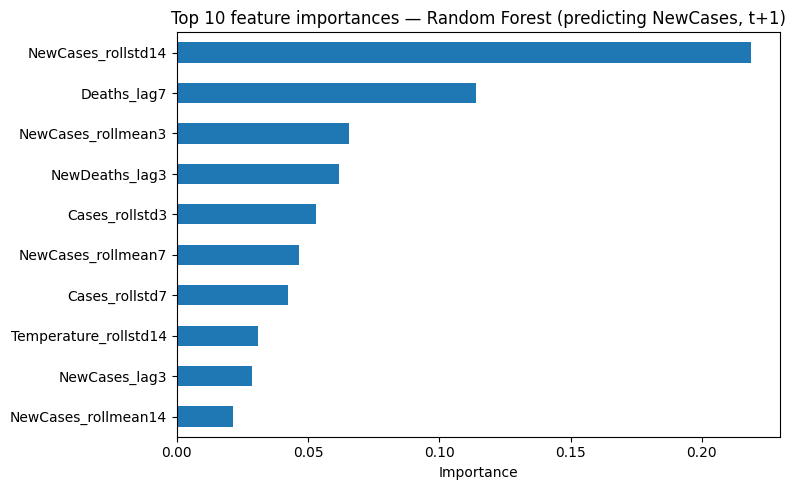

In [8]:
imp = run_B["importances"].head(10)
plt.figure(figsize=(8, 5))
imp.sort_values().plot(kind="barh")
plt.title("Top 10 feature importances — Random Forest (predicting NewCases, t+1)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()


## Predicted vs. actual (Target B: NewCases, test set)

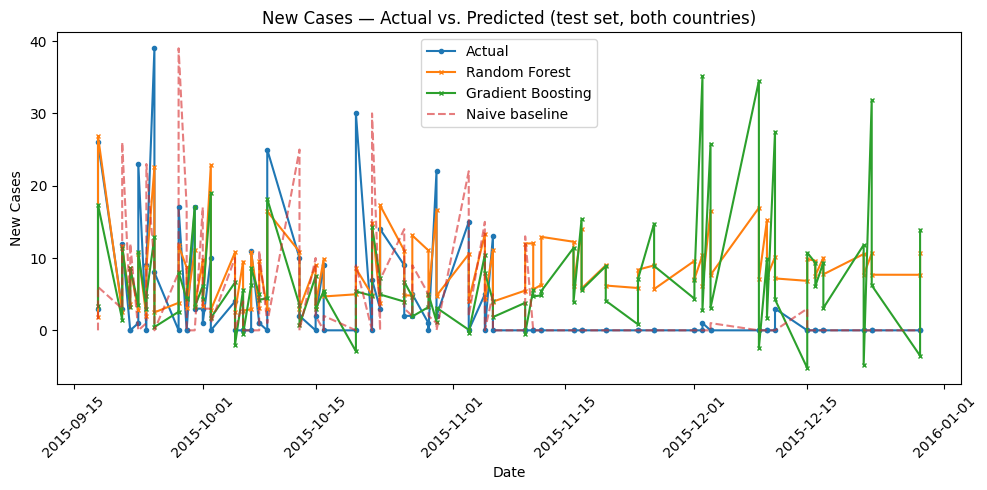

In [9]:
test = run_B["test"]
plt.figure(figsize=(10, 5))
plt.plot(test["Date"].values, run_B["y_test"].values, label="Actual", marker="o", markersize=3)
plt.plot(test["Date"].values, run_B["rf_pred"], label="Random Forest", marker="x", markersize=3)
plt.plot(test["Date"].values, run_B["gb_pred"], label="Gradient Boosting", marker="x", markersize=3)
plt.plot(test["Date"].values, run_B["naive_pred"], label="Naive baseline", linestyle="--", alpha=0.6)
plt.legend()
plt.title("New Cases — Actual vs. Predicted (test set, both countries)")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("predictions_vs_actual.png", dpi=150)
plt.show()


## Save models (for Member 3's Streamlit dashboard)

In [10]:
joblib.dump(run_B["rf"], "rf_model_newcases.pkl")
joblib.dump(run_B["gb"], "gb_model_newcases.pkl")
joblib.dump(run_B["feature_cols"], "feature_cols.pkl")
print("Saved: rf_model_newcases.pkl, gb_model_newcases.pkl, feature_cols.pkl")


Saved: rf_model_newcases.pkl, gb_model_newcases.pkl, feature_cols.pkl


## Summary

| | MAE | RMSE | R² | MASE |
|---|---|---|---|---|
| Random Forest (NewCases) | see output above | | | |
| Gradient Boosting (NewCases) | see output above | | | |
| Naive baseline (NewCases) | see output above | | | |

- Feature engineering: lag (1/2/3/7-step) and rolling (3/7/14-window) features,
  built per country, plus a derived `NewCases`/`NewDeaths` incident series and
  a `days_since_prev` reporting-gap feature.
- Chronological, per-country train/test split — no shuffling, no leakage.
- MASE implemented from scratch and used as the primary honesty check against
  a naive persistence baseline; **this is what caught the cumulative-target
  pitfall** in this dataset.
- Current models do not yet beat the naive baseline on the harder `NewCases`
  target — a legitimate finding given dataset size, and a natural handoff
  point to Member 3's additional data sources.